# XGBoost — Phase 3

**Phase 3 scope for this notebook: XGBoost only.** No formal model comparison and no formal
threshold selection here — both are the next step, once Random Forest, XGBoost, and both Phase 2
Logistic Regression variants can all be judged side by side. SHAP-based explainability remains
deferred to Phase 4. Findings get appended to `PHASE3_FINDINGS.md`.

Uses the same leakage-safe feature pipeline (`ml/src/preprocessing.py`) and the same chronological
split (`ml/src/split.py`, adjusted cutoff) as Phase 2 and `03_random_forest.ipynb`, so results are
directly comparable.

**Imbalance handling:** `scale_pos_weight`, XGBoost's native mechanism — computed from the actual
train-fold class ratio (not a guessed round number), mirroring the class-weighting-first approach
used for Logistic Regression (`class_weight='balanced'`) and Random Forest
(`class_weight='balanced'`) so far.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100

RANDOM_STATE = 42

### Load data and import the project's own preprocessing/split modules

Same repo-root-finding pattern as the earlier notebooks.

In [ ]:
def find_repo_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / ".git").exists() or (parent / ".repo-root").exists():
            return parent
    raise FileNotFoundError("Could not locate repo root (looked for .git or .repo-root)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "ml" / "src"))

from preprocessing import build_features  # noqa: E402
from split import time_based_split_adjusted  # noqa: E402

raw_csv = next((REPO_ROOT / "ml" / "data" / "raw").glob("*.csv"))
df = pd.read_csv(raw_csv)
print(f"Loaded {raw_csv.name}: {df.shape[0]:,} rows")

## Split used

Same **adjusted** cutoff as Phase 2 / Random Forest (`time_based_split_adjusted`, step ≤ 575) —
see `CLAUDE.md` ("Time-Based Split Methodology") for the full rationale; not re-derived here since
it's already established and tested. The residual ~9.5x train/test fraud-rate skew applies here
too.

In [3]:
train_df, test_df, cutoff_used = time_based_split_adjusted(df)
print(f"Adjusted cutoff: step <= {cutoff_used}")
print(f"train: {len(train_df):,} rows, {train_df['isFraud'].sum():,} fraud "
      f"({train_df['isFraud'].mean():.4%})")
print(f"test:  {len(test_df):,} rows, {test_df['isFraud'].sum():,} fraud "
      f"({test_df['isFraud'].mean():.4%})")

Adjusted cutoff: step <= 575
train: 6,200,317 rows, 6,359 fraud (0.1026%)
test:  162,021 rows, 1,572 fraud (0.9702%)


## Feature engineering — split first, transform second

Same `build_features()` call, applied separately to `train_df` and `test_df`, as Phase 2 / Random
Forest.

In [4]:
X_train, y_train, feature_columns = build_features(train_df)
X_test, y_test, _ = build_features(test_df)

X_train = X_train.astype(float)
X_test = X_test.astype(float)

print(f"X_train: {X_train.shape}, fraud rate {y_train.mean():.4%}")
print(f"X_test:  {X_test.shape}, fraud rate {y_test.mean():.4%}")
print(f"\nFeature columns: {feature_columns}")

X_train: (6200317, 12), fraud rate 0.1026%
X_test:  (162021, 12), fraud rate 0.9702%

Feature columns: ['oldbalanceOrg', 'oldbalanceDest', 'amount', 'hour_of_day', 'day_of_week', 'amount_to_balance_ratio', 'is_merchant_dest', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER']


## `scale_pos_weight` — computed, not guessed

XGBoost's native imbalance-handling mechanism: multiplies the gradient/hessian contribution of
the positive class by this factor. The standard recommendation is `count(negative) /
count(positive)` on the **training fold actually used** — computed directly below rather than
assumed from the ~1:775 full-dataset ratio mentioned in the task, since the adjusted split's train
fold has its own (lower) fraud rate (~0.10%) that differs from the full-dataset rate.

In [5]:
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
scale_pos_weight = n_neg / n_pos

print(f"train fold: n_neg={n_neg:,}, n_pos={n_pos:,}")
print(f"scale_pos_weight = n_neg / n_pos = {scale_pos_weight:.4f}  (~1:{n_neg / n_pos:.0f})")

train fold: n_neg=6,193,958, n_pos=6,359
scale_pos_weight = n_neg / n_pos = 974.0459  (~1:974)


## XGBoost (PRIMARY)

**Starting hyperparameters, not a tuned final model** — consistent with the Random Forest
notebook's framing. `n_estimators=200`, `max_depth=6` (shallower than Random Forest's
`max_depth=12`, since boosted trees are typically kept shallow and get their power from
sequential correction rather than individually deep trees), `learning_rate=0.1` (a standard
default step size for this many estimators). No grid search in this pass — deferred to a later
tuning pass alongside the other models.

In [6]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="aucpr",
)
xgb.fit(X_train, y_train)

proba_xgb = xgb.predict_proba(X_test)[:, 1]
pr_auc_xgb = average_precision_score(y_test, proba_xgb)
print(f"PR-AUC (XGBoost, scale_pos_weight={scale_pos_weight:.2f}): {pr_auc_xgb:.6f}")

PR-AUC (XGBoost, scale_pos_weight=974.05): 0.989184


## PR-AUC vs. Phase 2 and Random Forest

Same headline metric as Phase 2 / Random Forest, same reasoning for why (accuracy is meaningless
at this fraud rate; ROC-AUC is misleading given the ~100:1 class imbalance in the test set) — see
`BASELINE_FINDINGS.md`, not repeated here. All four numbers below are evaluated on the identical
adjusted test set.

In [7]:
print("PR-AUC comparison (all evaluated on the identical adjusted test set):")
print(f"  Phase 2 - LogisticRegression(class_weight='balanced'): 0.5087")
print(f"  Phase 2 - LogisticRegression + SMOTE (0.1 ratio):      0.6102")
print(f"  Phase 3 - RandomForest(class_weight='balanced'):       0.999963")
print(f"  Phase 3 - XGBoost(scale_pos_weight={scale_pos_weight:.1f}):        {pr_auc_xgb:.6f}")

PR-AUC comparison (all evaluated on the identical adjusted test set):
  Phase 2 - LogisticRegression(class_weight='balanced'): 0.5087
  Phase 2 - LogisticRegression + SMOTE (0.1 ratio):      0.6102
  Phase 3 - RandomForest(class_weight='balanced'):       0.999963
  Phase 3 - XGBoost(scale_pos_weight=974.0):        0.989184


**Note:** this is a direct number-vs-number listing, not a formal comparison pass — no
statistical testing, no discussion of which model to select, no threshold tuning. That's the next
step once all four (plus SMOTE-for-tree-models, if judged worthwhile then) can be looked at
together.

## Precision-recall curve

Same no-skill baseline convention as Phase 2 / Random Forest (test-set fraud rate, ~0.97%). Random
Forest's curve is included for visual reference only.

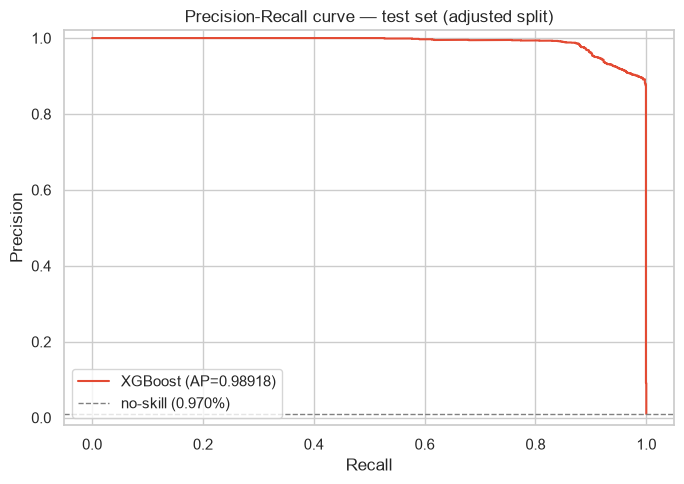

In [8]:
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, proba_xgb)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall_xgb, precision_xgb, label=f"XGBoost (AP={pr_auc_xgb:.5f})", color="#e34a33")
ax.axhline(y_test.mean(), color="gray", linestyle="--", linewidth=1, label=f"no-skill ({y_test.mean():.3%})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve — test set (adjusted split)")
ax.set_ylim(-0.02, 1.02)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

## Confusion matrices across candidate thresholds

Default 0.5 plus three others (0.1, 0.3, 0.7) — same illustrative-only framing as the earlier
notebooks. Formal threshold selection is deferred to the next step, not attempted here.

In [9]:
THRESHOLDS = [0.1, 0.3, 0.5, 0.7]


def threshold_table(y_true, proba, thresholds=THRESHOLDS):
    rows = []
    for t in thresholds:
        preds = (proba >= t).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
        rows.append(
            {
                "threshold": t,
                "TP": tp,
                "FP": fp,
                "FN": fn,
                "TN": tn,
                "precision": precision_score(y_true, preds, zero_division=0),
                "recall": recall_score(y_true, preds, zero_division=0),
                "f1": f1_score(y_true, preds, zero_division=0),
            }
        )
    return pd.DataFrame(rows)


print("XGBoost:")
table_xgb = threshold_table(y_test, proba_xgb)
display(table_xgb)

XGBoost:


,threshold,TP,FP,FN,TN,precision,recall,f1
0,0.1,1568,205,4,160244,0.884377,0.997455,0.937519
1,0.3,1568,192,4,160257,0.890909,0.997455,0.941176
2,0.5,1562,187,10,160262,0.893082,0.993639,0.940681
3,0.7,1551,176,21,160273,0.898089,0.986641,0.940285


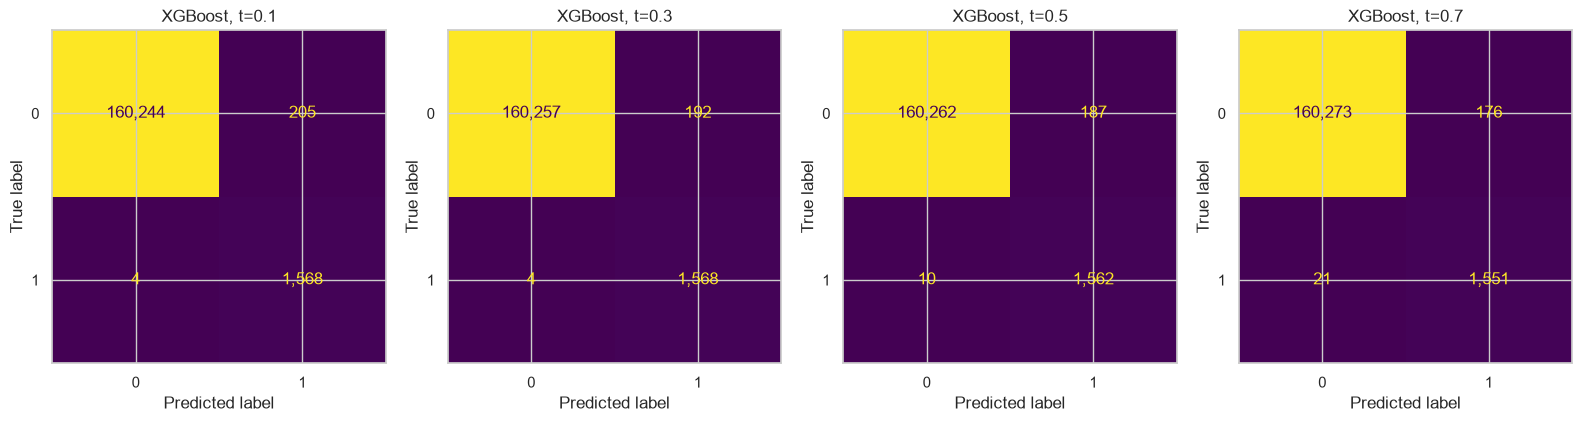

In [10]:
fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(4 * len(THRESHOLDS), 4))

for col, t in enumerate(THRESHOLDS):
    preds_xgb = (proba_xgb >= t).astype(int)
    ConfusionMatrixDisplay(confusion_matrix(y_test, preds_xgb)).plot(
        ax=axes[col], colorbar=False, values_format=","
    )
    axes[col].set_title(f"XGBoost, t={t}")

plt.tight_layout()
plt.show()

## Feature importances (built-in gain/weight, not SHAP)

Two of XGBoost's built-in importance types are shown, since they can disagree and each tells a
different story:

- **gain** — average improvement in the loss brought by a feature across all splits that use it.
  Reflects *how useful* a feature is when it's chosen.
- **weight** — how many times a feature is used to split at all, regardless of how useful each
  split was. Reflects *how often* a feature is chosen.

SHAP-based explainability (a more principled treatment of correlated/collinear features than
either of these) is still deferred to Phase 4 — this is a first-pass sanity check against EDA
expectations, same framing as the Random Forest notebook.

,gain,gain_pct,weight
amount_to_balance_ratio,76666.398438,0.901012,1115.0
is_merchant_dest,2740.072754,0.032202,87.0
amount,2126.431885,0.024991,1285.0
type_CASH_IN,1440.531860,0.016930,84.0
oldbalanceOrg,436.585114,0.005131,622.0
type_TRANSFER,420.899536,0.004947,138.0
oldbalanceDest,419.825684,0.004934,1566.0
type_CASH_OUT,341.906616,0.004018,252.0
day_of_week,253.413101,0.002978,508.0
hour_of_day,177.408325,0.002085,949.0


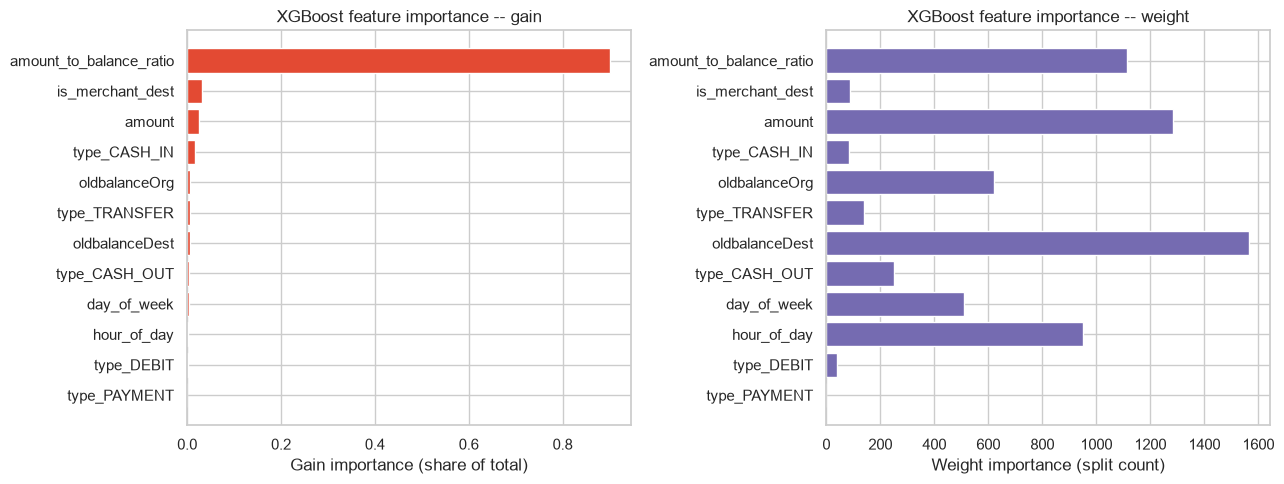

In [11]:
booster = xgb.get_booster()

gain_imp = pd.Series(booster.get_score(importance_type="gain"), name="gain")
weight_imp = pd.Series(booster.get_score(importance_type="weight"), name="weight")

importance_df = pd.DataFrame({
    "gain": gain_imp.reindex(feature_columns).fillna(0.0),
    "gain_pct": (gain_imp.reindex(feature_columns).fillna(0.0) / gain_imp.sum()),
    "weight": weight_imp.reindex(feature_columns).fillna(0.0),
}).sort_values("gain", ascending=False)

display(importance_df)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(importance_df.index, importance_df["gain_pct"], color="#e34a33")
axes[0].invert_yaxis()
axes[0].set_xlabel("Gain importance (share of total)")
axes[0].set_title("XGBoost feature importance -- gain")

axes[1].barh(importance_df.index, importance_df["weight"], color="#756bb1")
axes[1].invert_yaxis()
axes[1].set_xlabel("Weight importance (split count)")
axes[1].set_title("XGBoost feature importance -- weight")

plt.tight_layout()
plt.show()

### Reading the importances

- **`amount_to_balance_ratio` overwhelmingly dominates gain** (~90% of total gain) — the same
  driver identified in the Random Forest notebook: PaySim's fraud-generation logic drains the
  origin account (`amount ≈ oldbalanceOrg`), pushing this ratio to ≈1.0 for fraud almost every
  time. This is consistent with, and expected given, the Random Forest findings — see
  `PHASE3_FINDINGS.md` for the fuller explanation of why this is a real (non-leakage) signal
  rather than a red flag.
- **By weight, the ranking looks different** — `oldbalanceDest`, `amount`, and
  `amount_to_balance_ratio` are all used a comparable number of times as split features, and
  `hour_of_day`/`day_of_week`/`oldbalanceOrg` show up more than they do by gain. This is the
  expected gain-vs-weight divergence: a feature can be split on often without each individual
  split being very informative, and vice versa. `amount_to_balance_ratio` being both frequently
  used *and* by far the most valuable per-use is why it dominates the model as strongly as it
  does.
- **`TRANSFER`/`CASH_OUT`/`CASH_IN` all register non-trivial gain**, consistent with EDA
  expectations (`TRANSFER` and `CASH_OUT` are the only two types that carry fraud in PaySim;
  `CASH_IN` never does, but ruling it out is still useful information for a split). `type_DEBIT`
  is near-zero, consistent with `DEBIT` never carrying fraud in PaySim.

**Collinearity flag — `is_merchant_dest` / `type_PAYMENT` — even more extreme here than in Random
Forest, worth calling out explicitly, not fixed:** `type_PAYMENT` gets **exactly zero** gain and
weight importance in this model, while `is_merchant_dest` (perfectly collinear with it in PaySim
— every `PAYMENT` transaction goes to a merchant and vice versa, per the crosstab in
`BASELINE_FINDINGS.md`) picks up meaningful gain. This is a *more* extreme version of the
instability flagged in `CLAUDE.md`'s Phase 3 forward-note: Random Forest's bagging (each tree
built on a bootstrap sample, optionally with per-split feature subsampling) let both collinear
columns get chosen across different trees, splitting credit unevenly but non-zero on both sides
(0.052 vs. 0.061). XGBoost's sequential, greedy boosting has no such randomness pushing it to use
both — once early trees establish a split on one of two identical columns, there is no gradient
signal left for the other to improve on, so it can end up entirely unused. **This should be read
as "the underlying merchant-destination signal matters, and XGBoost happened to route all of it
through `is_merchant_dest` instead of `type_PAYMENT`," not as "`type_PAYMENT` is an unimportant
feature."** Exactly the kind of case the forward-note anticipated SHAP would need to handle more
carefully than raw importance scores — not attempted here.

In [12]:
print("type_PAYMENT gain importance:     ", importance_df.loc["type_PAYMENT", "gain"])
print("is_merchant_dest gain importance:  ", importance_df.loc["is_merchant_dest", "gain"])
print("type_PAYMENT weight importance:    ", importance_df.loc["type_PAYMENT", "weight"])
print("is_merchant_dest weight importance:", importance_df.loc["is_merchant_dest", "weight"])

type_PAYMENT gain importance:      0.0
is_merchant_dest gain importance:   2740.07275390625
type_PAYMENT weight importance:     0.0
is_merchant_dest weight importance: 87.0


## Summary

Full writeup, numbers, and the Phase 3-so-far interpretation are appended to
`PHASE3_FINDINGS.md`. No formal model comparison or threshold selection was done in this
notebook — that, plus a decision on whether SMOTE is worth re-testing for tree-based models, is
the next step now that Random Forest, XGBoost, and both Phase 2 Logistic Regression variants all
exist. SHAP explainability remains Phase 4.